# Introduction to Machine Learning
## A 90-Minute Journey for Actuaries

**Course Duration:** 90 minutes  
**Target Audience:** Actuaries and quantitative professionals  
**Learning Objective:** Understand core ML paradigms, model selection, and practical implementation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ktnspr/py4ac/blob/main/05_intro_machine_learning.ipynb) [![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ktnspr/py4ac/blob/main/05_intro_machine_learning.ipynb)

---

### What We'll Cover Today

This session introduces the fundamental concepts and practical tools for machine learning, with special emphasis on applications relevant to the actuarial profession. By the end, you will understand:

- The three learning paradigms and when to apply each
- How to select appropriate model complexity
- How to encode, scale, and engineer features
- How to build, evaluate, and optimize classification and regression models

In [1]:
# Colab setup: fetch helper module if running in Google Colab
import sys
if "google.colab" in sys.modules:
    !wget -qN https://raw.githubusercontent.com/ktnspr/py4ac/main/mytools.py

In [2]:
# Essential imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Import helper functions from mytools
from mytools import (
    generate_polynomial_data,
    generate_two_blobs,
    plot_model_selection_regression,
    plot_classification_boundaries,
    generate_multiclass_data,
    plot_confusion_matrix_custom,
    load_titanic_data
)

# Set visualization defaults
#sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Avoid truncation of DataFrame output in Jupyter
pd.set_option('display.expand_frame_repr', False)

# Display all columns in the DataFrame output
pd.set_option('display.max_columns', None)

# Define a separator for better readability
sep = "=" * 50

print("All imports successful!")


All imports successful!


## 1. Learning Paradigms

Machine learning encompasses three primary paradigms, each suited to different types of problems:

### Three Core Paradigms

| **Paradigm** | **Description** | **Use Case** |
|---|---|---|
| **Supervised Learning** | Learn from labeled data: input X → output y | Predicting claims, customer churn |
| **Unsupervised Learning** | Find patterns in unlabeled data | Customer segmentation, anomaly detection |
| **Reinforcement Learning** | Learn through interaction & rewards | Optimal decision-making, control systems |

**In this session**, we focus on **Supervised Learning**, which splits into two main branches:

- **Classification:** Predict categorical outcomes (e.g., "Will claim occur?" → Yes/No)
- **Regression:** Predict continuous outcomes (e.g., "What will be the claim amount?" → €5,000)


## 2. Model Selection — Regression (Underfitting vs. Overfitting)

A critical aspect of machine learning is choosing the right model complexity. Too simple → underfitting. Too complex → overfitting. Let's visualize this with polynomial regression.

### The Bias-Variance Trade-off

- **Underfitting (High Bias):** Model is too simple to capture patterns → poor performance on both training and test data
- **Overfitting (High Variance):** Model memorizes noise → excellent training performance, poor test performance
- **Sweet Spot:** Balanced complexity that generalizes well to new data

High variance - tu je mišljena varianca med npr 100imi poizkusi in varianco med parametri. Če bi v naslednjem poizkusu naredil fitting na novih točkah, bi v overfittingu prišla popolnoma nova krivulja (drugi parametri, velika varianca med krivuljama). Če bi to naredili v high bias modelu, bi verjetno dobili podobno premico, parametri bi bili blizu (nizka varicna).
Ta varianca tu ni mišljena varianca med točkami in krivuljami, ker očitno v overfittingu nimaš variance! Imaš pa večjo varinco med točkami in premico v high bias.
**Ideja je, da najdeš pravo razmerje, da nisi preveč high bias in tudi ne overfitting!**

Below, we generate 20 noisy samples from a cubic polynomial and fit models of varying complexity:


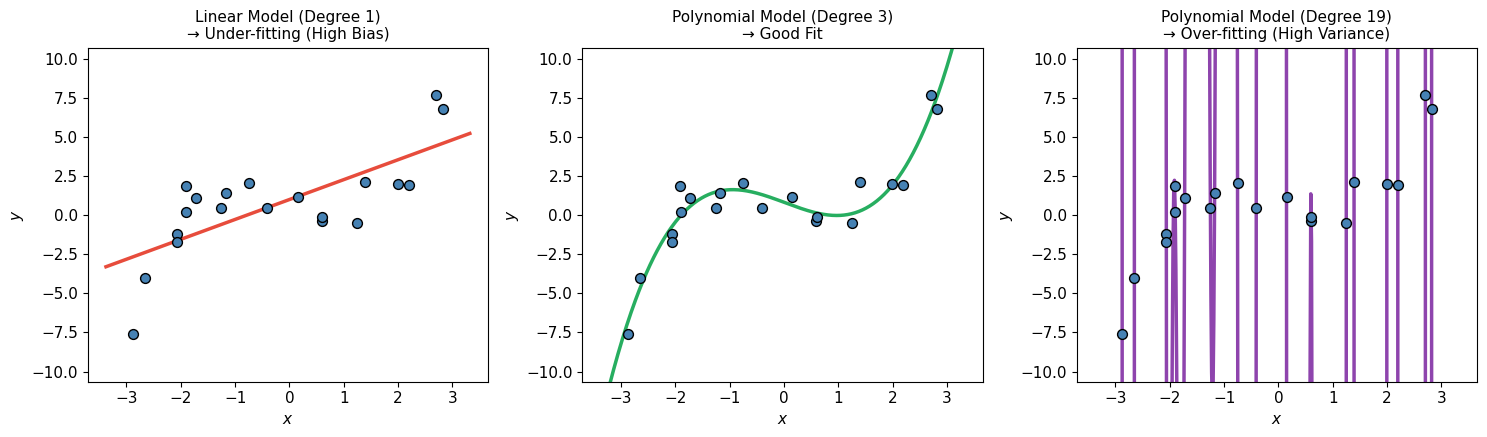

<Figure size 1000x600 with 0 Axes>


Polynomial Regression — Model Complexity:
Left:   Linear model (underfitting) — captures the trend but misses curvature
Middle: Cubic model (good fit) — reasonable complexity
Right:  Degree-19 polynomial (overfitting) — wiggles to fit every point


In [7]:
# Generate sample data from a cubic polynomial with noise
X, y = generate_polynomial_data(n=20, noise=1.0, seed=42)

# Visualize the three regimes: underfitting, good fit, overfitting
plot_model_selection_regression(X, y)
plt.tight_layout()
plt.show()

print(f"\n{sep}\nPolynomial Regression — Model Complexity:\n{sep}")
print("Left:   Linear model (underfitting) — captures the trend but misses curvature")
print("Middle: Cubic model (good fit) — reasonable complexity")
print("Right:  Degree-19 polynomial (overfitting) — wiggles to fit every point")

### Key Insight: Polynomial Features as Feature Engineering

Notice how the cubic model captures the underlying pattern well. This is an example of **feature engineering**—we created polynomial features ($x^2$, $x^3$) from the original feature $x$. This is our first hint that domain knowledge and feature creation can substantially improve model performance.

Counterinuitive take-away: Linear Regression can capture non-linear relationships if we engineer the right features. The

   $ \text{Polynomial Regression: } y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \epsilon $

is linear in parameters, but non-linear in features!


## 3. Model Selection — Classification (Decision Boundaries)

Different algorithms learn different decision boundaries. Let's explore how four popular classifiers separate two blob classes:


In [8]:
# Generate two-blob classification data
X, y = generate_two_blobs(n=300, seed=42)

# Define classifiers
classifiers = [
    DecisionTreeClassifier(random_state=42, max_depth=4),
    LogisticRegression(random_state=42, max_iter=1000),
    SVC(kernel='rbf', random_state=42),
    MLPClassifier(hidden_layer_sizes=(20, 20), max_iter=1000, random_state=42)
]

titles = [
    'Decision Tree',
    'Logistic Regression',
    'Support Vector Machine (RBF)',
    'Neural Network'
]

Now let's visualize how each classifier draws its decision boundary on the same data.

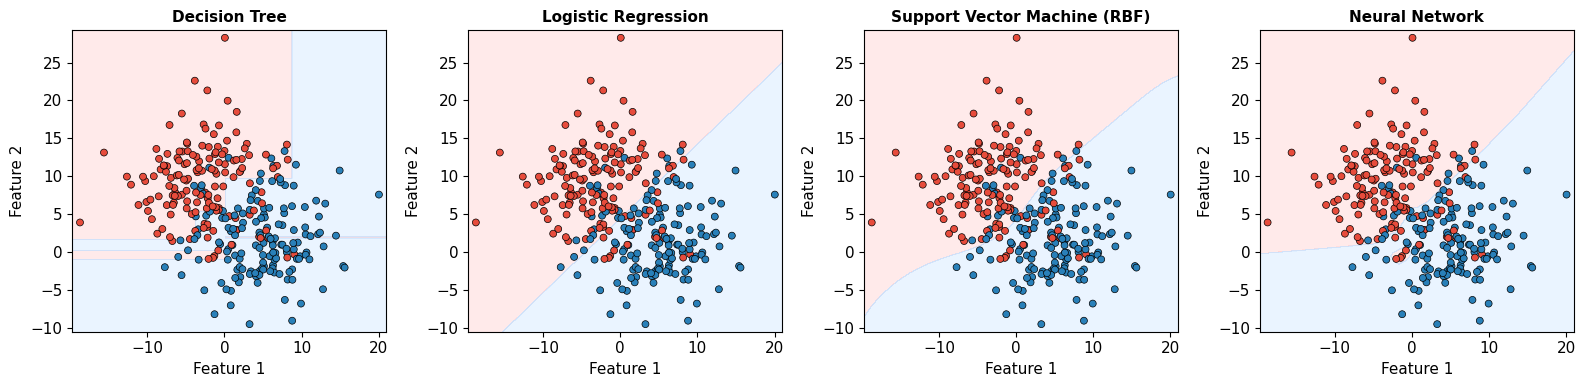


Decision Boundaries:
Decision Tree:        Axis-aligned splits, piecewise constant boundaries
Logistic Regression:  Linear boundary (can't capture non-linear patterns)
SVM (RBF):            Non-linear, smooth boundary
Neural Network:       Flexible, complex boundary


In [ ]:
# Plot decision boundaries
plot_classification_boundaries(X, y, classifiers, titles, figsize=(16, 4))
plt.show()

print(f"\n{sep}\nDecision Boundaries:\n{sep}")
print("Decision Tree:        Axis-aligned splits, piecewise constant boundaries")
print("Logistic Regression:  Linear boundary (can't capture non-linear patterns)")
print("SVM (RBF):            Non-linear, smooth boundary")
print("Neural Network:       Flexible, complex boundary")

### Observations

1. **Decision Tree** creates rectangular regions (axis-aligned splits)
2. **Logistic Regression** produces a linear boundary—works here, but not always
3. **Support Vector Machine** learns smooth, non-linear boundaries (RBF kernel)
4. **Neural Network** is highly flexible and can capture intricate patterns

The "best" algorithm depends on your data structure, interpretability needs, and computational constraints.


### Same Four Classifiers — Now Deliberately Overfitted

What happens when we crank each model's complexity to the extreme?

| **Classifier** | **What we changed** | **Effect** |
|---|---|---|
| Decision Tree | `max_depth=None` (unlimited) | Grows until every leaf is pure → super-jagged boundary |
| Logistic Regression | Degree-6 polynomial features + very weak regularisation (`C=1e6`) | Linear model in a 27-dim feature space → wiggly boundary |
| SVM (RBF) | `gamma=5, C=1000` | Each point gets a tiny "bubble" of influence → boundary hugs every point |
| Neural Network | 4 hidden layers of 256 units, 5 000 iterations | Massive capacity → boundary contorts to fit noise |

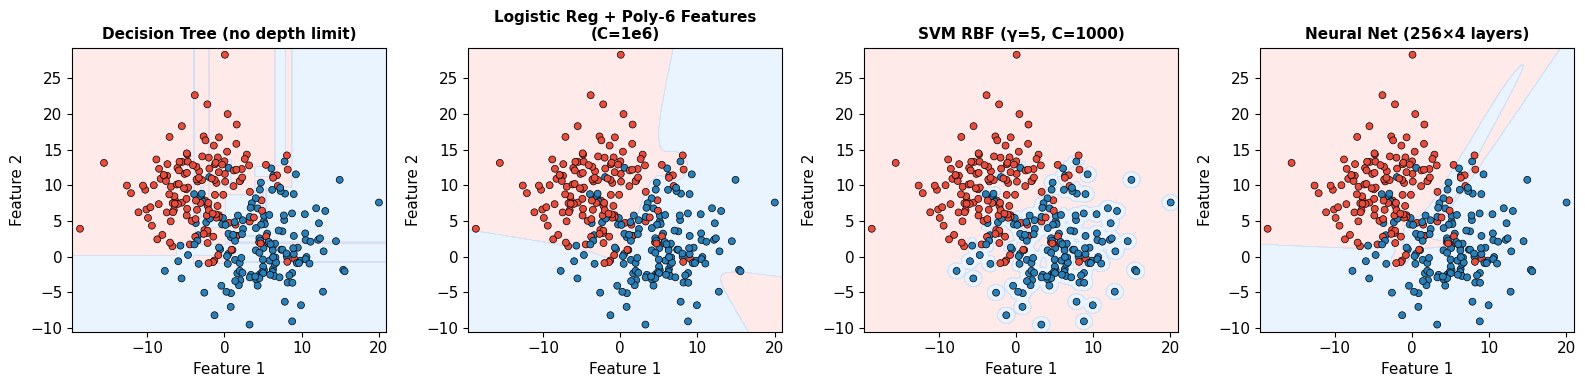

<Figure size 1000x600 with 0 Axes>


Overfitted Decision Boundaries:
All four models now hug the training data far too closely.
Decision Tree:      Extremely jagged, axis-aligned rectangles everywhere
Logistic Reg+Poly:  Wiggly boundary from high-dim feature space
SVM (RBF):          Tight 'bubbles' around individual points
Neural Network:     Complex, contorted boundary capturing noise


In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Same data as before
X_blobs, y_blobs = generate_two_blobs(n=300, seed=42)

# Overfitted classifiers
classifiers_overfit = [
    DecisionTreeClassifier(random_state=42, max_depth=None),          # no depth limit
    make_pipeline(
        PolynomialFeatures(degree=6, include_bias=False),
        LogisticRegression(C=1e6, max_iter=5000, random_state=42)     # near-zero regularisation
    ),
    SVC(kernel='rbf', gamma=5, C=1000, random_state=42),             # tiny RBF width, huge C
    MLPClassifier(hidden_layer_sizes=(256, 256, 256, 256),
                  max_iter=5000, random_state=42)                      # very large network
]

titles_overfit = [
    'Decision Tree (no depth limit)',
    'Logistic Reg + Poly-6 Features\n(C=1e6)',
    'SVM RBF (γ=5, C=1000)',
    'Neural Net (256×4 layers)'
]

plot_classification_boundaries(X_blobs, y_blobs, classifiers_overfit, titles_overfit, figsize=(16, 4))
plt.suptitle('Overfitted Decision Boundaries', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print(f"\n{sep}\nOverfitted Decision Boundaries:\n{sep}")
print("All four models now hug the training data far too closely.")
print("Decision Tree:      Extremely jagged, axis-aligned rectangles everywhere")
print("Logistic Reg+Poly:  Wiggly boundary from high-dim feature space")
print("SVM (RBF):          Tight 'bubbles' around individual points")
print("Neural Network:     Complex, contorted boundary capturing noise")

## 4. Data Encoding

Most machine learning algorithms require numerical inputs. Categorical variables must be encoded:

Z načinom [0,1,0] - ne narediš nobenega vrstnega reda, kar je pri določenih kategorijah nujno. Ker če bi dal npr red = 1, blue=2, avtomatsko dodaš vrstni red in pri določenih kategorijah to ni ok.

| **Feature Type** | **Encoding Method** | **Example** |
|---|---|---|
| **Nominal (unordered)** | One-Hot Encoding | Color: Red → [1,0,0], Blue → [0,1,0] |
| **Ordinal (ordered)** | Label/Map | Risk level: Low→1, Medium→2, High→3 |
| **Numerical** | No encoding | Age, Claim amount |

### One-Hot Encoding (Nominal Features)

For unordered categories, create a binary column per category:

```python
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

df = pd.DataFrame({'policy_type': ['car', 'home', 'car', 'life']})
df_encoded = pd.get_dummies(df, columns=['policy_type'])
```

### Ordinal Encoding (Ordered Features)

For ordered categories, map values to integers that preserve the order:

```python
df = pd.DataFrame({'risk_level': ['low', 'medium', 'high', 'low']})
risk_map = {'low': 1, 'medium': 2, 'high': 3}
df['risk_level_encoded'] = df['risk_level'].map(risk_map)
```

### *Reading Exercise 1: Data Encoding*

**Task:** Read, how a small DataFrame containing categorical features is encoded.


In [12]:
# Sample insurance data
df_insurance = pd.DataFrame({
    'policy_type': ['car', 'home', 'car', 'life', 'home'],
    'risk_level': ['low', 'high', 'medium', 'low', 'high'],
    'age': [25, 45, 35, 60, 50]
})

print(f"\n{sep}\nOriginal DataFrame:\n{sep}")
print(df_insurance)


# One-hot encode 'policy_type' using pd.get_dummies
df_encoded = pd.get_dummies(df_insurance, columns=['policy_type'], drop_first=False) #drop_first=True, ti enega da stran. Imaš še vedno vse infromacije, manj stolpcev (če je false, false, pomeni da je bil prvi true)

# Ordinal encode 'risk_level' using .map()
risk_mapping = {'low': 1, 'medium': 2, 'high': 3}
df_encoded['risk_level_encoded'] = df_encoded['risk_level'].map(risk_mapping)
df_encoded = df_encoded.drop('risk_level', axis=1)

print(f"\n{sep}\nEncoded DataFrame:\n{sep}")
print(df_encoded)



Original DataFrame:
  policy_type risk_level  age
0         car        low   25
1        home       high   45
2         car     medium   35
3        life        low   60
4        home       high   50

Encoded DataFrame:
   age  policy_type_car  policy_type_home  policy_type_life  risk_level_encoded
0   25             True             False             False                   1
1   45            False              True             False                   3
2   35             True             False             False                   2
3   60            False             False              True                   1
4   50            False              True             False                   3


## 5. Scaling / Standardization

Many algorithms (e.g., SVM, Neural Networks, Logistic Regression) are sensitive to feature magnitude. Scaling brings features to comparable ranges.

### StandardScaler (Standardization)

$$z = \frac{x - \mu}{\sigma}$$

Transforms features to mean=0, standard deviation=1.

### MinMaxScaler (Normalization)

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Scales features to the range [0, 1].

### Code Example


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sample data
X_sample = np.array([[10, 1000],
                      [20, 2000],
                      [30, 3000]])

print(f"\n{sep}\nOriginal Data:\n{sep}")
print(X_sample)


Original Data:
[[  10 1000]
 [  20 2000]
 [  30 3000]]


**StandardScaler** transforms each feature to have mean ≈ 0 and standard deviation ≈ 1.

In [ ]:
# Standardization
scaler_standard = StandardScaler()
X_standardized = scaler_standard.fit_transform(X_sample)
print(f"\n{sep}\nAfter StandardScaler (mean≈0, std≈1):\n{sep}")
print(X_standardized)


After StandardScaler (mean≈0, std≈1):
[[-1.22474487 -1.22474487]
 [ 0.          0.        ]
 [ 1.22474487  1.22474487]]


**MinMaxScaler** rescales each feature to the range [0, 1].

In [ ]:
# Normalization
scaler_minmax = MinMaxScaler()
X_normalized = scaler_minmax.fit_transform(X_sample)
print(f"\n{sep}\nAfter MinMaxScaler (range [0,1]):\n{sep}")
print(X_normalized)


After MinMaxScaler (range [0,1]):
[[0.  0. ]
 [0.5 0.5]
 [1.  1. ]]


## 6. Feature Engineering

**Feature engineering** is the art of creating new features from raw data. It often has bigger impact on model performance than algorithm choice.

### We've Already Seen Feature Engineering!

In Section 2, we created polynomial features ($x$, $x^2$, $x^3$) from a single input. This transformation allowed a cubic model to fit the data.

### Actuarial Examples

- **Combined Features:** `claim_ratio = claim_amount / vehicle_value`
- **Polynomial Features:** `age^2` to capture non-linear age effects
- **Interactions:** `premium_group * vehicle_type` to capture combined effects of nominal variables as matrices (e.g. young drivers in sports cars)
- **Domain Ratios:** `average_claim_per_policy = total_claims / policy_count`

### Key Principle

**Domain knowledge is your best tool.** Understand your data, consult with subject matter experts, and craft features that capture meaningful patterns.


## 7. Train/Test Split

A fundamental principle: evaluate on data the model has **never seen** before.

### The Workflow

1. Split data: typically 80% training, 20% testing
2. Fit the model on training data
3. Evaluate on test data

### Critical: Avoid Data Leakage

**Data Leakage** occurs when test set information "leaks" into training:

```python
# ❌ WRONG: Scaling before split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Fit on ALL data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
```

```python
# ✓ CORRECT: Scaling after split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)      # Fit only on training
X_test_scaled = scaler.transform(X_test)            # Transform test using training statistics
```


In [13]:
# Example: correct train/test split and scaling
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Step 1: Split first
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

print(f"\n{sep}\nTrain/Test Split:\n{sep}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

# Step 2: Scale using only training statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n{sep}\nResult:\n{sep}")
print("✓ Data correctly split and scaled (no leakage)")


Train/Test Split:
Training set size: 120
Test set size:     30

Result:
✓ Data correctly split and scaled (no leakage)


## 8. Evaluation Metrics

The choice of metric depends on your problem and business objectives.

### Regression: Root Mean Squared Error (RMSE)

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

### Classification Metrics

For a binary classification problem (e.g., claim/no-claim):

### Confusion Matrix

|  | **Predicted Positive** | **Predicted Negative** |
|---|:---:|:---:|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

### Derived Metrics

- **Accuracy:** $\frac{\text{TP} + \text{TN}}{\text{Total}}$ — Overall correctness
- **Precision:** $\frac{\text{TP}}{\text{TP} + \text{FP}}$ — Of predicted positives, how many are correct?
- **Recall:** $\frac{\text{TP}}{\text{TP} + \text{FN}}$ — Of actual positives, how many did we find?
- **F1-Score:** $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ — Harmonic mean

### When to Use Each Metric

| **Metric** | **When to Use** |
|---|---|
| Accuracy | Balanced classes, general purpose |
| Precision | Minimize false positives (e.g., emergency brake system) |
| Recall | Minimize false negatives (e.g., disease diagnosis) |
| F1-Score | Need a balance between precision and recall |

Let's see these metrics in action:

In [18]:
from sklearn.metrics import classification_report, accuracy_score

# Example predictions vs. actual labels
y_true = np.array([1, 0, 1, 1, 0, 1, 1, 0, 1, 1])
y_pred = np.array([0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

print(f"\n{sep}\nClassification Report:\n{sep}")
print(classification_report(y_true, y_pred, target_names=['No Claim (0)', 'Claim (1)']))


Classification Report:
              precision    recall  f1-score   support

No Claim (0)       0.50      0.67      0.57         3
   Claim (1)       0.83      0.71      0.77         7

    accuracy                           0.70        10
   macro avg       0.67      0.69      0.67        10
weighted avg       0.73      0.70      0.71        10



We can also compute individual metrics for more targeted analysis.

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Individual metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\n{sep}\nIndividual Metrics:\n{sep}")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-Score:  {f1:.3f}")


Individual Metrics:
Accuracy:  0.700
Precision: 0.833
Recall:    0.714
F1-Score:  0.769


### Nerd Talk: Why Do the Two Classes Get Different Scores?

Precision and recall differ between "No Claim (0)" and "Claim (1)" because the errors are **not symmetric**. It helps to swap the perspective:

- **FP for Claim (1) = FN for No Claim (0)** — predicting "Claim (1)" when there is none hurts *precision* of "Claim (1)" but hurts *recall* of "No Claim (0)".
- **FN for Claim (1) = FP for No Claim (0)** — missing a real claim hurts *recall* of "Claim (1)" but hurts *precision* of "No Claim (0)".

Every false positive for one class is a false negative for the other. So the same confusion matrix, read row-by-row, yields a different precision/recall pair for each class.

**Viewed from "Claim (1)" (positive = 1):**

|  | **Pred Claim (1)** | **Pred No Claim (0)** |
|---|:---:|:---:|
| **Actual Claim (1)** | TP = 5 | FN = 2 |
| **Actual No Claim (0)** | FP = 1 | TN = 2 |

→ Precision = 5/(5+1) = 0.83 · Recall = 5/(5+2) = 0.71

**Viewed from "No Claim (0)" (positive = 0) — just swap the labels:**

|  | **Pred No Claim (0)** | **Pred Claim (1)** |
|---|:---:|:---:|
| **Actual No Claim (0)** | TP = 2 | FN = 1 |
| **Actual Claim (1)** | FP = 2 | TN = 5 |

→ Precision = 2/(2+2) = 0.50 · Recall = 2/(2+1) = 0.67

Same numbers, different names — that's why each class gets its own precision and recall.

## 9. Decision Trees with scikit-learn

Decision Trees are interpretable, easy to use, and effective across many domains.

### The sklearn Interface

All sklearn estimators follow a consistent interface:

```python
clf = SomeClassifier()          # Create instance
clf.fit(X_train, y_train)        # Fit to training data
y_pred = clf.predict(X_test)     # Make predictions
score = clf.score(X_test, y_test) # Evaluate
```

### *Reading Exercise 3: Train and Evaluate a Decision Tree*

**Task:** Train a Decision Tree classifier on the blob data, split it properly, and generate a classification report.

In [20]:
# Use the two-blob data from earlier
X, y = generate_two_blobs(n=300, seed=42)

# Step 1: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Create and train a Decision Tree
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)

# Step 3: Make predictions
y_pred = tree_clf.predict(X_test)

# Step 4: Evaluate
print(f"\n{sep}\nDecision Tree — Classification Report:\n{sep}")
print(classification_report(y_test, y_pred))

print(f"\n{sep}\nTest Accuracy:\n{sep}")
print(f"{tree_clf.score(X_test, y_test):.3f}")


Decision Tree — Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.72      0.70        29
           1       0.72      0.68      0.70        31

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60


Test Accuracy:
0.700


## 10. Random Forests

A **Random Forest** is an ensemble of many decision trees. Instead of relying on a single tree, we:

1. Build multiple trees on bootstrap samples of the data
2. Introduce randomness (e.g., random feature subsets for splits)
3. Average predictions across all trees

### Key Advantages

- **Reduced Overfitting:** Averaging multiple trees is more robust than a single tree
- **Black-box Model:** Often performs very well, but less interpretable
- **Parallelizable:** Trees are independent and can be trained in parallel

### Comparison: Single Tree vs. Random Forest


In [21]:
# Use the blob data - this time with more noise
X, y = generate_two_blobs(n=300, seed=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Single Decision Tree
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)
tree_acc = tree_clf.score(X_test, y_test)

Now let's train a Random Forest — an ensemble of many decision trees — on the same data and compare.

In [22]:
# Random Forest
rf_clf = RandomForestClassifier(n_estimators=5, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)
rf_acc = rf_clf.score(X_test, y_test)

print(f"\n{sep}\nDecision Tree vs. Random Forest:\n{sep}")
print(f"Decision Tree Test Accuracy:  {tree_acc:.3f}")
print(f"Random Forest Test Accuracy:  {rf_acc:.3f}")

print(f"\n{sep}\nRandom Forest Benefits:\n{sep}")
print("- Often achieves better accuracy")
print("- More robust to overfitting")
print("- Can handle large feature sets")
print("- Slower to train than single tree, but still fast for most datasets")


Decision Tree vs. Random Forest:
Decision Tree Test Accuracy:  0.700
Random Forest Test Accuracy:  0.817

Random Forest Benefits:
- Often achieves better accuracy
- More robust to overfitting
- Can handle large feature sets
- Slower to train than single tree, but still fast for most datasets


## 11. Neural Networks (MLP)

A **Multi-Layer Perceptron (MLP)** is a simple feedforward neural network. It consists of:

1. An **input layer** that receives the features
2. One or more **hidden layers** of neurons, each applying a non-linear activation function
3. An **output layer** that produces the prediction

### How It Works

Each neuron computes a weighted sum of its inputs, adds a bias, and passes the result through an activation function (typically ReLU). During training, the network adjusts all weights via **backpropagation** to minimize the loss.

### Key Characteristics

| **Aspect** | **MLP** |
|---|---|
| **Strengths** | Flexible, can learn complex non-linear patterns |
| **Weaknesses** | Requires scaled data, less interpretable, sensitive to hyperparameters |
| **When to use** | When simpler models underperform and you have enough data |

In scikit-learn, `MLPClassifier` provides a simple interface — no deep learning framework needed.

### Comparison: Decision Tree vs. Random Forest vs. Neural Network

In [23]:
# Reuse the same blob data and split from Section 10
# X_train, X_test, y_train, y_test are already defined

# The MLP needs scaled data (just like Logistic Regression and SVM)
scaler_mlp = StandardScaler()
X_train_scaled_mlp = scaler_mlp.fit_transform(X_train)
X_test_scaled_mlp = scaler_mlp.transform(X_test)

# Neural Network: one hidden layer with 16 neurons, early stopping to prevent overfitting
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(16,),     # single hidden layer, 16 neurons
    activation='relu',            # ReLU activation function
    solver='adam',                # Adam optimizer
    max_iter=500,                 # maximum training epochs
    early_stopping=True,          # stop when validation score stops improving
    random_state=42
)
mlp_clf.fit(X_train_scaled_mlp, y_train)
mlp_acc = mlp_clf.score(X_test_scaled_mlp, y_test)

# Compare all three models
print(f"\n{sep}\nModel Comparison on Blob Data:\n{sep}")
print(f"  Decision Tree:     {tree_acc:.3f}")
print(f"  Random Forest:     {rf_acc:.3f}")
print(f"  Neural Network:    {mlp_acc:.3f}")

print(f"\n{sep}\nMLP Details:\n{sep}")
print(f"Architecture:    {mlp_clf.hidden_layer_sizes} hidden layer(s)")
print(f"Stopped at epoch: {mlp_clf.n_iter_} / {mlp_clf.max_iter}")

print(f"\n{sep}\nNote:\n{sep}")
print("On this simple 2D dataset, all three models perform")
print("similarly well. The MLP's advantage becomes more apparent")
print("with higher-dimensional data and complex decision boundaries.")


Model Comparison on Blob Data:
  Decision Tree:     0.700
  Random Forest:     0.817
  Neural Network:    0.850

MLP Details:
Architecture:    (16,) hidden layer(s)
Stopped at epoch: 33 / 500

Note:
On this simple 2D dataset, all three models perform
similarly well. The MLP's advantage becomes more apparent
with higher-dimensional data and complex decision boundaries.


## 12. Classifiers in scikit-learn (selection)
### Quick Reference: Classifiers in scikit-learn

We've now seen Decision Trees, Random Forests, and Neural Networks in action. Here is a broader overview of classifiers available in scikit-learn — all follow the same `.fit()` / `.predict()` interface:

| **Algorithm** | **sklearn class** | **Key characteristics** |
|---|---|---|
| Logistic Regression | `LogisticRegression` | Linear, fast, interpretable coefficients, good baseline |
| Decision Tree | `DecisionTreeClassifier` | Non-linear, interpretable rules, prone to overfitting |
| Random Forest | `RandomForestClassifier` | Ensemble of trees, robust, handles many features well |
| Gradient Boosting | `GradientBoostingClassifier` | Sequential ensemble, often top accuracy, slower to train |
| AdaBoost | `AdaBoostClassifier` | Boosting with weak learners, sensitive to outliers |
| SVM (linear) | `LinearSVC` | Linear boundary, fast on large datasets, no probabilities |
| SVM (kernel) | `SVC` | Non-linear via kernels (RBF, poly), needs scaling |
| k-Nearest Neighbors | `KNeighborsClassifier` | Instance-based, no training phase, slow at prediction time |
| Naive Bayes | `GaussianNB` | Very fast, assumes feature independence, good for text |
| Neural Network | `MLPClassifier` | Flexible non-linear, needs scaling, many hyperparameters |

**Rule of thumb:** Start with Logistic Regression (interpretable baseline), then try Random Forest or Gradient Boosting. Use SVMs or MLPs if you need non-linear boundaries and can afford less interpretability.

## 13. Hyperparameter Optimization with GridSearchCV

**Hyperparameters** are settings you choose before training (e.g., `max_depth`, `n_estimators`). Finding good values is crucial.

**GridSearchCV** systematically tries combinations and uses cross-validation to estimate performance.

### Example: Optimizing Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV

# Use the blob data
X, y = generate_two_blobs(n=300, seed=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a grid of hyperparameters to search
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [3, 15, 50]
}

# Create base classifier
rf = RandomForestClassifier(random_state=42)

# GridSearchCV tries all combinations
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\n{sep}\nGridSearchCV Results:\n{sep}")
print(f"Best parameters:          {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")
print(f"Test set score (best params): {grid_search.score(X_test, y_test):.3f}")


GridSearchCV Results:
Best parameters:          {'max_depth': 3, 'n_estimators': 3}
Best cross-validation score: 0.846
Test set score (best params): 0.833


### What's Happening?

1. GridSearchCV creates a 4 × 3 = 12 combinations of hyperparameters
2. For each, it uses 5-fold cross-validation on the training set
3. It selects the combination with the best average CV score
4. The best estimator is retrained on all training data and returned
5. We evaluate the final model on the held-out test set

**Tip:** Use GridSearchCV inside your train/test pipeline to avoid data leakage.


## 14. Feature Importance — Which Features Actually Matter?

After training a model, a natural question arises: **which features drive the predictions?**

This is especially important for actuaries, where:
- **Regulators** may require explanations for pricing or reserving decisions
- **Business stakeholders** want to understand the key risk drivers
- **Model validation** needs to confirm that important features make domain sense

### Permutation Importance (Model-Agnostic)

**Permutation Importance** measures how much a model's performance drops when a single feature is randomly shuffled. The idea is simple:

1. Compute the model's baseline score on the test set
2. For each feature: shuffle its values, re-score the model, and measure the drop
3. A large drop means the feature is important — the model relied on it

This approach works with **any** model (not just tree-based ones) and evaluates importance on held-out data, making it more trustworthy than training-based measures.

We use `sklearn.inspection.permutation_importance` to compute this.

### Example: Titanic Survival Prediction

The Titanic dataset is a classic — who survived the sinking? Features include passenger class, sex, age, fare, and family size. Let's find out which ones the model actually relies on.


Titanic Dataset:
Passengers: 712
Features:   ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Survival rate: 40.4%

Baseline Test Accuracy:
0.783


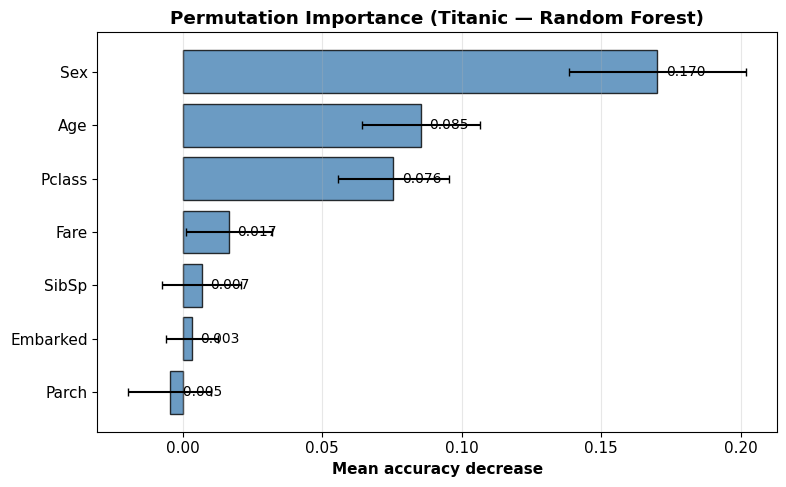


Permutation Importance (mean ± std over 30 repeats):
  Sex           0.1702 ± 0.0318
  Age           0.0853 ± 0.0211
  Pclass        0.0755 ± 0.0199
  Fare          0.0166 ± 0.0156
  SibSp         0.0068 ± 0.0142
  Embarked      0.0033 ± 0.0093
  Parch         -0.0047 ± 0.0149


In [24]:
from sklearn.inspection import permutation_importance

# --- Load and prepare Titanic data ---
X_titanic, y_titanic, feature_names = load_titanic_data()

print(f"\n{sep}\nTitanic Dataset:\n{sep}")
print(f"Passengers: {len(y_titanic)}")
print(f"Features:   {feature_names}")
print(f"Survival rate: {y_titanic.mean():.1%}")

# Split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

# Train a Random Forest
rf_titanic = RandomForestClassifier(n_estimators=100, random_state=42)
rf_titanic.fit(X_train_t, y_train_t)

baseline_acc = rf_titanic.score(X_test_t, y_test_t)

print(f"\n{sep}\nBaseline Test Accuracy:\n{sep}")
print(f"{baseline_acc:.3f}")

# Compute Permutation Importance on the TEST set
perm_result = permutation_importance(
    rf_titanic, X_test_t, y_test_t,
    n_repeats=30, random_state=42, scoring='accuracy'
)

# Sort by importance
sorted_idx = perm_result.importances_mean.argsort()[::-1]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(feature_names))
ax.barh(y_pos, perm_result.importances_mean[sorted_idx],
        xerr=perm_result.importances_std[sorted_idx],
        color='steelblue', alpha=0.8, edgecolor='black', capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.invert_yaxis()
ax.set_xlabel('Mean accuracy decrease', fontweight='bold')
ax.set_title('Permutation Importance (Titanic — Random Forest)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, idx in enumerate(sorted_idx):
    val = perm_result.importances_mean[idx]
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print results
print(f"\n{sep}\nPermutation Importance (mean ± std over 30 repeats):\n{sep}")
for i in sorted_idx:
    mean = perm_result.importances_mean[i]
    std = perm_result.importances_std[i]
    print(f"  {feature_names[i]:12s}  {mean:.4f} ± {std:.4f}")

In [28]:
X_titanic

array([[ 3.    ,  0.    , 22.    , ...,  0.    ,  7.25  ,  0.    ],
       [ 1.    ,  1.    , 38.    , ...,  0.    , 71.2833,  1.    ],
       [ 3.    ,  1.    , 26.    , ...,  0.    ,  7.925 ,  0.    ],
       ...,
       [ 1.    ,  1.    , 19.    , ...,  0.    , 30.    ,  0.    ],
       [ 1.    ,  0.    , 26.    , ...,  0.    , 30.    ,  1.    ],
       [ 3.    ,  0.    , 32.    , ...,  0.    ,  7.75  ,  2.    ]])

In [29]:
y_titanic #1=survive

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,

### Interpreting the Results

**Sex** is by far the strongest predictor — "women and children first" was a real policy on the Titanic. **Fare** and **Pclass** (passenger class) also rank high, reflecting the well-documented survival advantage of wealthier passengers with cabins on upper decks. **Age** contributes moderately, consistent with the priority given to children. Features like **Embarked** and **SibSp** have minimal impact.

### Key Takeaways

- **Permutation Importance is model-agnostic:** It works with any classifier or regressor — not just tree-based models. You can apply the same technique to Logistic Regression, SVMs, or Neural Networks.
- **Always compute on the test set:** Using the training set can give misleading results for overfit models.
- **Error bars matter:** The `n_repeats` parameter (here: 30) gives us standard deviations. A feature with high mean importance but also high variance deserves closer investigation.
- **Watch out for correlated features:** If two features carry similar information, permutation importance may underestimate both — because shuffling one still leaves the other intact. In actuarial practice, this is common (e.g., age and years of driving experience). On the Titanic, Fare and Pclass are correlated, which may explain why neither alone shows extreme importance.
- **Actuarial relevance:** Feature importance helps explain model decisions to regulators, validates that the model captures genuine risk drivers, and highlights which data is most valuable to collect and maintain.

## 15. *Reading Exercise: Comprehensive Classification Pipeline*

**Task:** Build classification reports for multiple algorithms on the blob dataset.

You will see:
1. Generate two-blob data
2. Split into train/test
3. Train Logistic Regression, SVM, and Neural Network
4. Evaluate each with classification_report
5. Compare performance


Logistic Regression:
Best parameters:          {'C': 0.1, 'solver': 'lbfgs'}
Best CV score:            0.846
Test Accuracy:            0.833

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.85      0.79      0.82        29
     Class 1       0.82      0.87      0.84        31

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60


Support Vector Machine:
Best parameters:          {'C': 0.1, 'gamma': 'scale'}
Best CV score:            0.858
Test Accuracy:            0.817

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.72      0.79        29
     Class 1       0.78      0.90      0.84        31

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60


Neural Netw

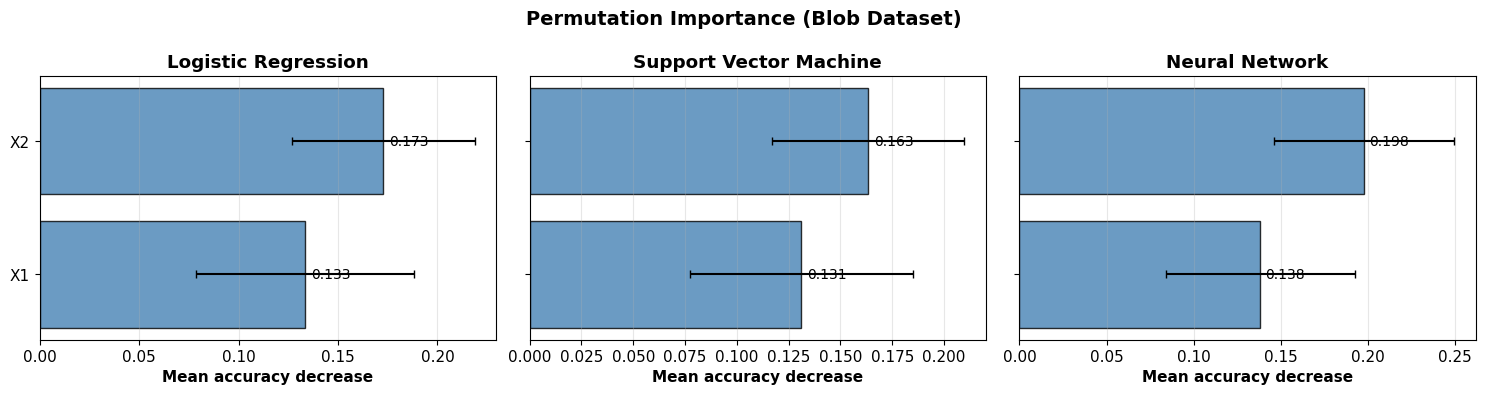


Permutation Importance — Logistic Regression (mean ± std over 30 repeats):
  X2            0.1728 ± 0.0458
  X1            0.1333 ± 0.0549

Permutation Importance — Support Vector Machine (mean ± std over 30 repeats):
  X2            0.1633 ± 0.0464
  X1            0.1311 ± 0.0539

Permutation Importance — Neural Network (mean ± std over 30 repeats):
  X2            0.1978 ± 0.0518
  X1            0.1383 ± 0.0543


In [25]:
# Step 1: Generate and split data
X, y = generate_two_blobs(n=300, seed=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Scale the data (important for LR, SVM, NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Define classifiers with hyperparameter grids for tuning
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs']
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.1, 1]
    },
    'Neural Network': {
        'hidden_layer_sizes': [(10,), (20, 20), (50, 20)],
        'alpha': [0.0001, 0.001, 0.01]
    }
}

base_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Neural Network': MLPClassifier(max_iter=1000, random_state=42)
}

# Step 4: Hyperparameter tuning with GridSearchCV, then evaluate
blob_feature_names = ['X1', 'X2']
classifiers = {}   # will hold the best estimators
results = {}

for name in base_classifiers:
    grid_search = GridSearchCV(
        base_classifiers[name], param_grids[name],
        cv=5, scoring='accuracy', n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)

    # Store the best estimator
    best_clf = grid_search.best_estimator_
    classifiers[name] = best_clf

    # Evaluate on the test set
    y_pred = best_clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{sep}\n{name}:\n{sep}")
    print(f"Best parameters:          {grid_search.best_params_}")
    print(f"Best CV score:            {grid_search.best_score_:.3f}")
    print(f"Test Accuracy:            {acc:.3f}")
    print(f"\n{sep}\nClassification Report:\n{sep}")
    print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

print(f"\n{sep}\nSummary of Accuracies (after GridSearchCV tuning):\n{sep}")
for name, acc in results.items():
    print(f"  {name:30s}: {acc:.3f}")

# Step 5: Feature Importance (Permutation Importance for each tuned classifier)
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, len(classifiers), figsize=(5 * len(classifiers), 4), sharey=True)

for ax, (name, clf) in zip(axes, classifiers.items()):
    perm_result = permutation_importance(
        clf, X_test_scaled, y_test,
        n_repeats=30, random_state=42, scoring='accuracy'
    )
    sorted_idx = perm_result.importances_mean.argsort()[::-1]
    y_pos = np.arange(len(blob_feature_names))

    ax.barh(y_pos, perm_result.importances_mean[sorted_idx],
            xerr=perm_result.importances_std[sorted_idx],
            color='steelblue', alpha=0.8, edgecolor='black', capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([blob_feature_names[i] for i in sorted_idx])
    ax.invert_yaxis()
    ax.set_xlabel('Mean accuracy decrease', fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    for i, idx in enumerate(sorted_idx):
        val = perm_result.importances_mean[idx]
        ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=10)

plt.suptitle('Permutation Importance (Blob Dataset)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Print permutation importance for each classifier
for name, clf in classifiers.items():
    perm_result = permutation_importance(
        clf, X_test_scaled, y_test,
        n_repeats=30, random_state=42, scoring='accuracy'
    )
    sorted_idx = perm_result.importances_mean.argsort()[::-1]
    print(f"\n{sep}\nPermutation Importance — {name} (mean ± std over 30 repeats):\n{sep}")
    for i in sorted_idx:
        mean = perm_result.importances_mean[i]
        std = perm_result.importances_std[i]
        print(f"  {blob_feature_names[i]:12s}  {mean:.4f} ± {std:.4f}")

### Reflection

- Which classifier performed best? Why might that be?
- Did scaling help? (Try commenting out the scaling step for SVM and NN—what happens?)
- What trade-offs exist between accuracy and interpretability?
- In an actuarial context, which metric (accuracy, precision, recall) might matter most?


In [26]:
X

array([[ 6.33236087e+00, -1.03269886e-01],
       [ 7.83284113e+00, -6.33443063e+00],
       [-2.57668375e+00,  3.72573148e+00],
       [ 7.37536574e+00,  9.62206422e-01],
       [ 6.08875312e+00,  1.23501737e+01],
       [-3.03069202e+00,  8.36155379e+00],
       [-1.43872890e+00,  2.78559223e+00],
       [ 6.34865872e+00,  1.13540239e+01],
       [-8.52880466e-01,  1.38920118e+01],
       [ 6.81967493e+00,  1.13834507e+01],
       [-5.51239107e+00,  7.55581738e+00],
       [-5.45602141e+00,  1.32622966e+01],
       [ 1.60352694e+00,  2.91006788e+00],
       [-2.48363034e+00,  7.84135046e+00],
       [ 1.22554992e+01,  4.66771990e+00],
       [-2.02380988e+00,  1.38575111e+01],
       [-3.70714757e+00,  4.68997065e+00],
       [ 8.21052282e+00,  1.21838812e+01],
       [-5.15799864e+00,  1.15806233e+01],
       [ 4.50477393e+00,  2.00503081e+00],
       [-7.38260597e+00,  1.29497091e+01],
       [-4.22277021e+00,  5.00289978e+00],
       [ 4.57864497e+00, -2.51310217e+00],
       [ 4.

In [27]:
y

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1])

---

## Summary

In this 90-minute session, you have learned:

1. **Learning Paradigms:** Supervised (classification & regression), Unsupervised, Reinforcement
2. **Model Complexity:** Balance between underfitting (bias) and overfitting (variance)
3. **Data Preparation:** Encoding, scaling, feature engineering
4. **Workflow Best Practices:** Train/test split, avoiding data leakage
5. **Evaluation:** Metrics for regression and classification
6. **Algorithms:** Decision Trees, Random Forests, Logistic Regression, SVM, Neural Networks
7. **Optimization:** Using GridSearchCV to tune hyperparameters
8. **Feature Importance:** Using Permutation Importance to understand which features drive predictions

### Key Takeaways for Actuaries

- Machine learning can enhance reserve prediction, pricing, and risk assessment
- Careful data preparation (encoding, scaling, feature engineering) often matters more than algorithm choice
- Always evaluate on held-out test data
- **Feature importance** helps explain model decisions to regulators and validates that models capture genuine risk drivers
- Interpretability is often valued in actuarial applications—consider decision trees and logistic regression
- Domain expertise drives feature engineering—collaborate with your risk team

### Next Steps

- Explore real actuarial datasets
- Experiment with different feature engineering strategies
- Use permutation importance to validate your models and communicate results
- Consider your specific business objectives when choosing evaluation metrics
- Stay curious and iterate!

---

**Created for:** Introduction to Machine Learning for Actuaries  
**Duration:** 90 minutes  
**Tools:** Python, scikit-learn, pandas, matplotlib